## RNN - Recurent Neural Network 
### to predict Google stock price


#### before working in jupyter, instal this in ubunto terminal:
- sudo app install pip
- python3 -m pip install scikit-learn
- python3 -m pip install pandas
- python3 -m pip install seaborn


### Import libraries:

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from pylab import rcParams
plt.rcParams["figure.dpi"]=300
import seaborn as sns
sns.set("talk", "ticks", font_scale=1, font="Calibri")

In [2]:
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

### Early Data Analysis

In [3]:
df = pd.read_csv("google_stock.csv")

In [4]:
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,GOOG,2016-06-14 00:00:00+00:00,718.27,722.47,713.1200,716.48,1306065,718.27,722.47,713.1200,716.48,1306065,0.0,1.0
1,GOOG,2016-06-15 00:00:00+00:00,718.92,722.98,717.3100,719.00,1214517,718.92,722.98,717.3100,719.00,1214517,0.0,1.0
2,GOOG,2016-06-16 00:00:00+00:00,710.36,716.65,703.2600,714.91,1982471,710.36,716.65,703.2600,714.91,1982471,0.0,1.0
3,GOOG,2016-06-17 00:00:00+00:00,691.72,708.82,688.4515,708.65,3402357,691.72,708.82,688.4515,708.65,3402357,0.0,1.0
4,GOOG,2016-06-20 00:00:00+00:00,693.71,702.48,693.4100,698.77,2082538,693.71,702.48,693.4100,698.77,2082538,0.0,1.0


In [5]:
df.shape

(1258, 14)

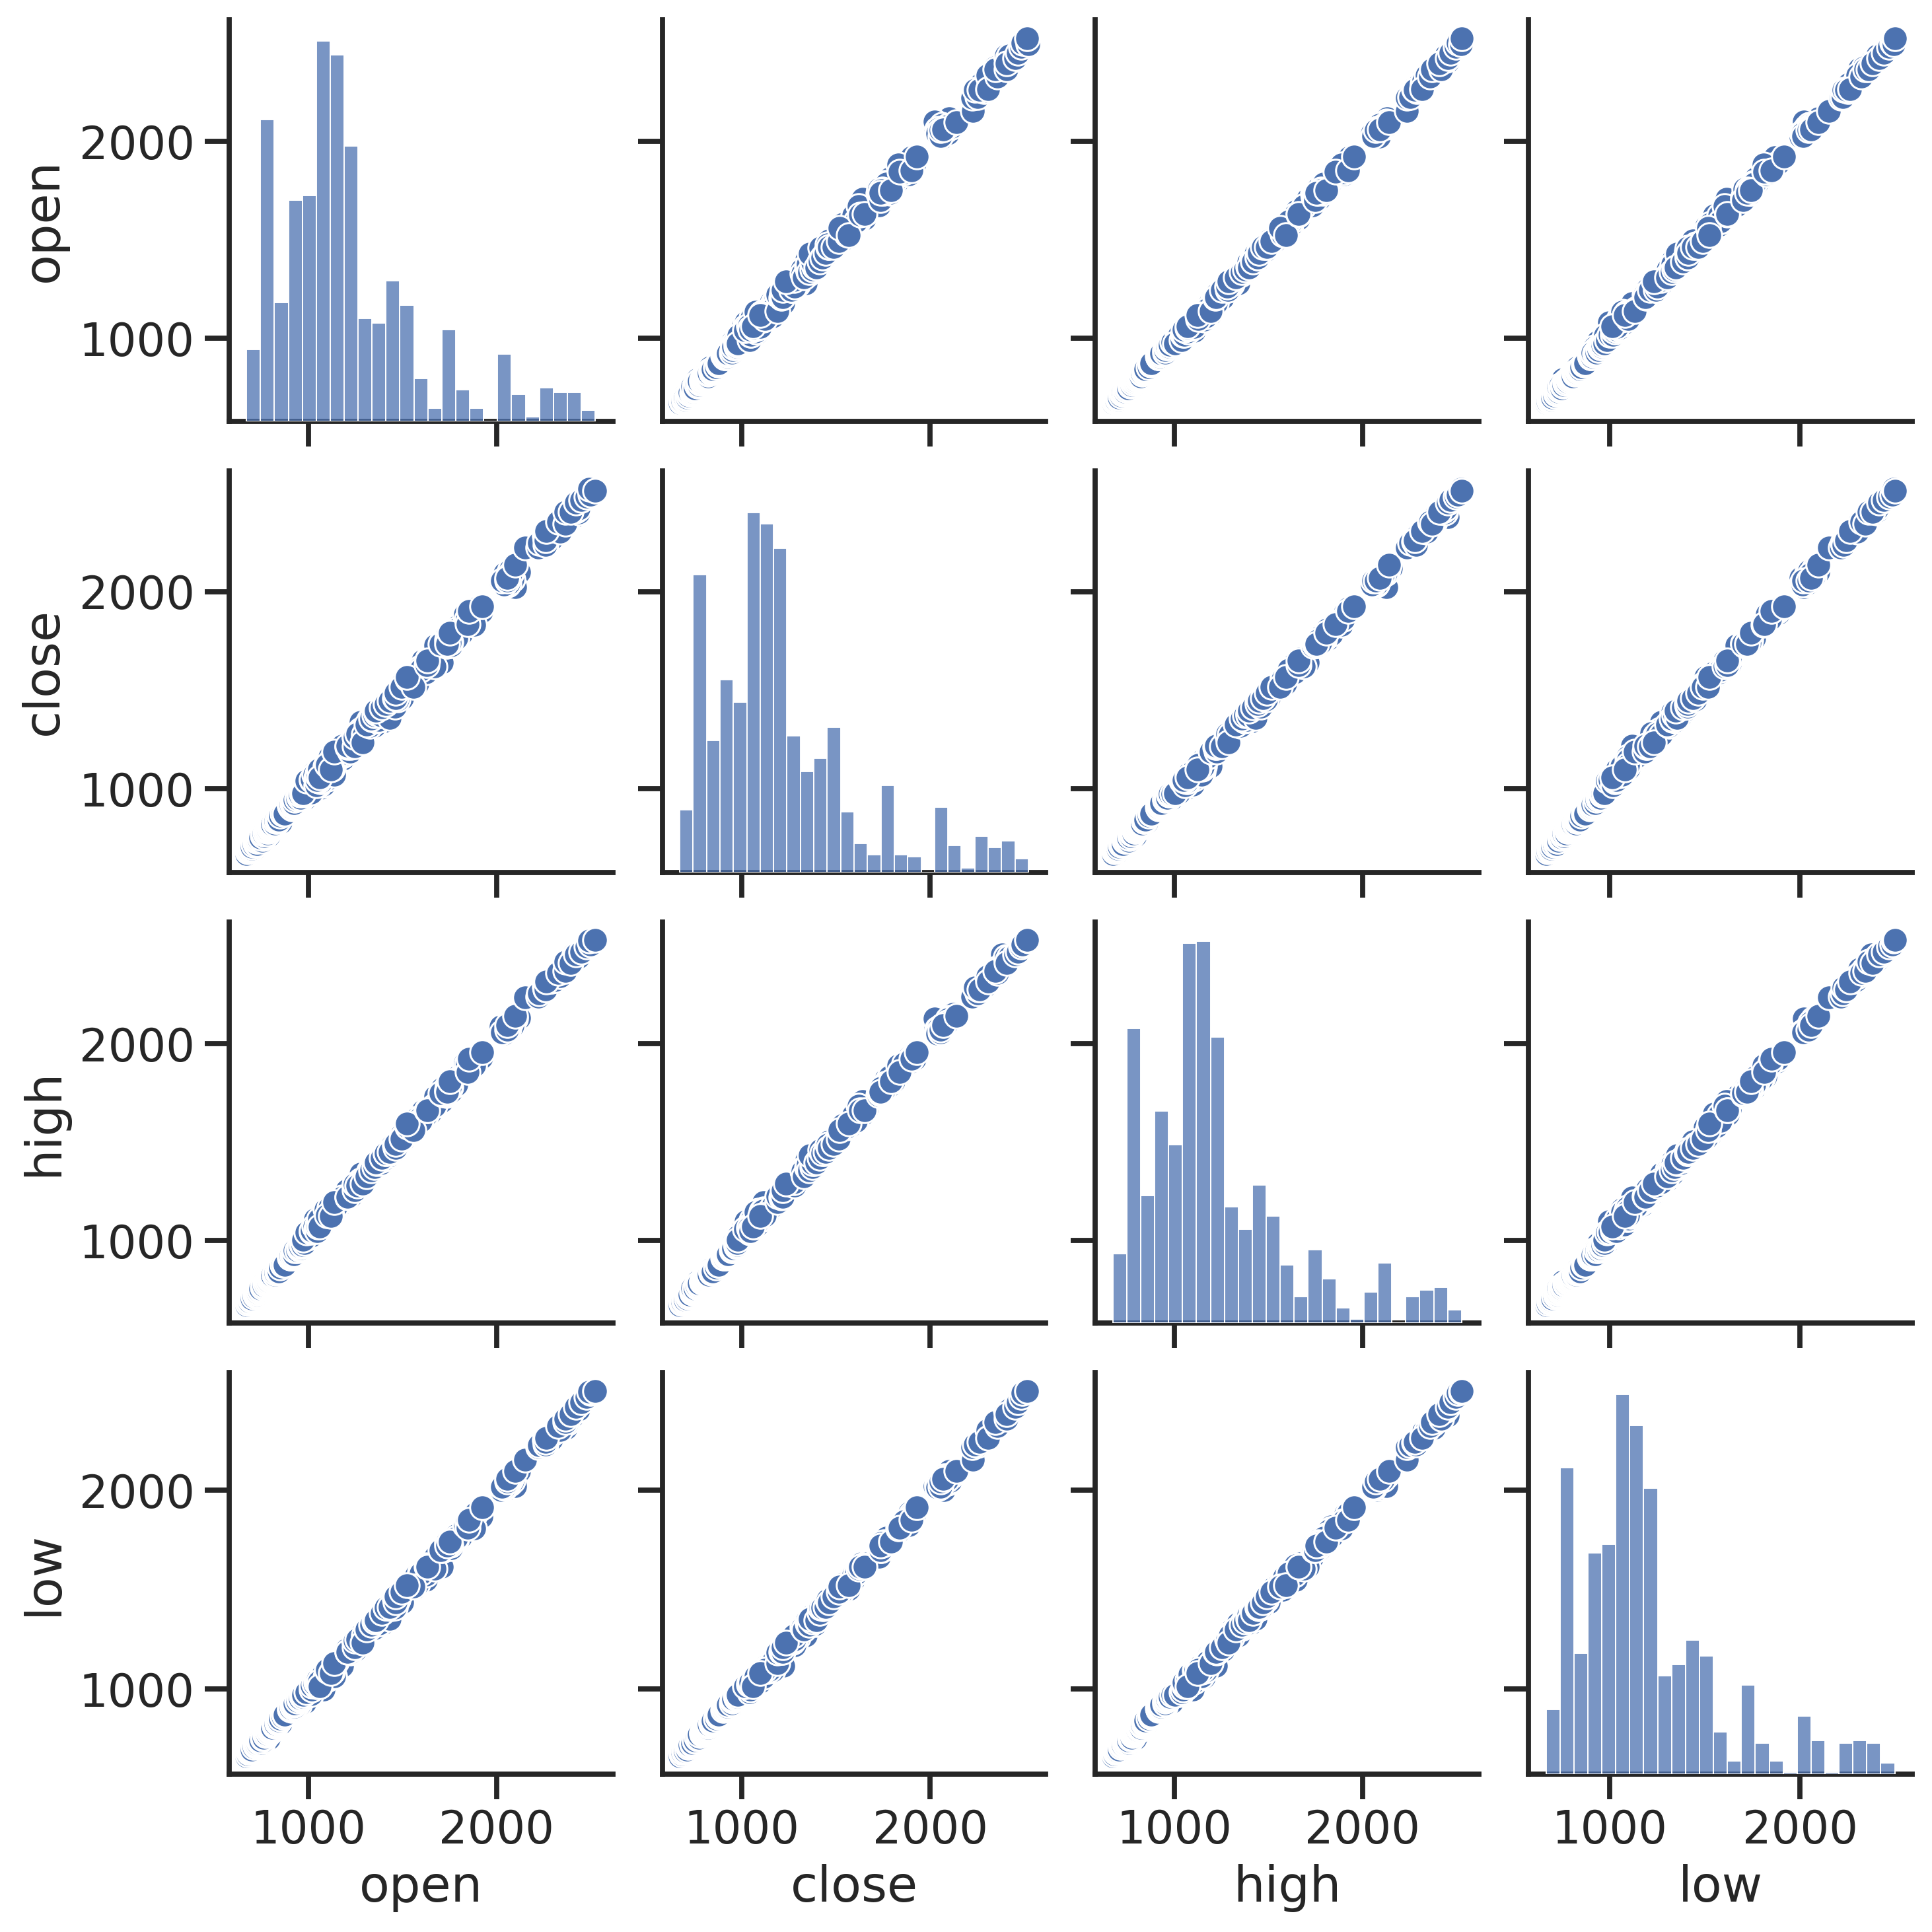

In [23]:
sns.pairplot(df[['open', 'close', 'high', 'low']])

In [6]:
df.info() # check for missing values, data types, column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   symbol       1258 non-null   object 
 1   date         1258 non-null   object 
 2   close        1258 non-null   float64
 3   high         1258 non-null   float64
 4   low          1258 non-null   float64
 5   open         1258 non-null   float64
 6   volume       1258 non-null   int64  
 7   adjClose     1258 non-null   float64
 8   adjHigh      1258 non-null   float64
 9   adjLow       1258 non-null   float64
 10  adjOpen      1258 non-null   float64
 11  adjVolume    1258 non-null   int64  
 12  divCash      1258 non-null   float64
 13  splitFactor  1258 non-null   float64
dtypes: float64(10), int64(2), object(2)
memory usage: 137.7+ KB


In [7]:
df.describe()

,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.0,1258.0
mean,1216.317067,1227.430934,1204.176430,1215.260779,1.601590e+06,1216.317067,1227.430936,1204.176436,1215.260779,1.601590e+06,0.0,1.0
std,383.333358,387.570872,378.777094,382.446995,6.960172e+05,383.333358,387.570873,378.777099,382.446995,6.960172e+05,0.0,0.0
min,668.260000,672.300000,663.284000,671.000000,3.467530e+05,668.260000,672.300000,663.284000,671.000000,3.467530e+05,0.0,1.0
25%,960.802500,968.757500,952.182500,959.005000,1.173522e+06,960.802500,968.757500,952.182500,959.005000,1.173522e+06,0.0,1.0
50%,1132.460000,1143.935000,1117.915000,1131.150000,1.412588e+06,1132.460000,1143.935000,1117.915000,1131.150000,1.412588e+06,0.0,1.0
75%,1360.595000,1374.345000,1348.557500,1361.075000,1.812156e+06,1360.595000,1374.345000,1348.557500,1361.075000,1.812156e+06,0.0,1.0
max,2521.600000,2526.990000,2498.290000,2524.920000,6.207027e+06,2521.600000,2526.990000,2498.290000,2524.920000,6.207027e+06,0.0,1.0


In [17]:
close_df = df.iloc[:, 2].values

In [18]:
close_df

array([ 718.27,  718.92,  710.36, ..., 2491.4 , 2521.6 , 2513.93])

In [19]:
type(close_df)

numpy.ndarray

### visualize data

findfont: Font family ['Calibri'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Calibri'] not found. Falling back to DejaVu Sans.


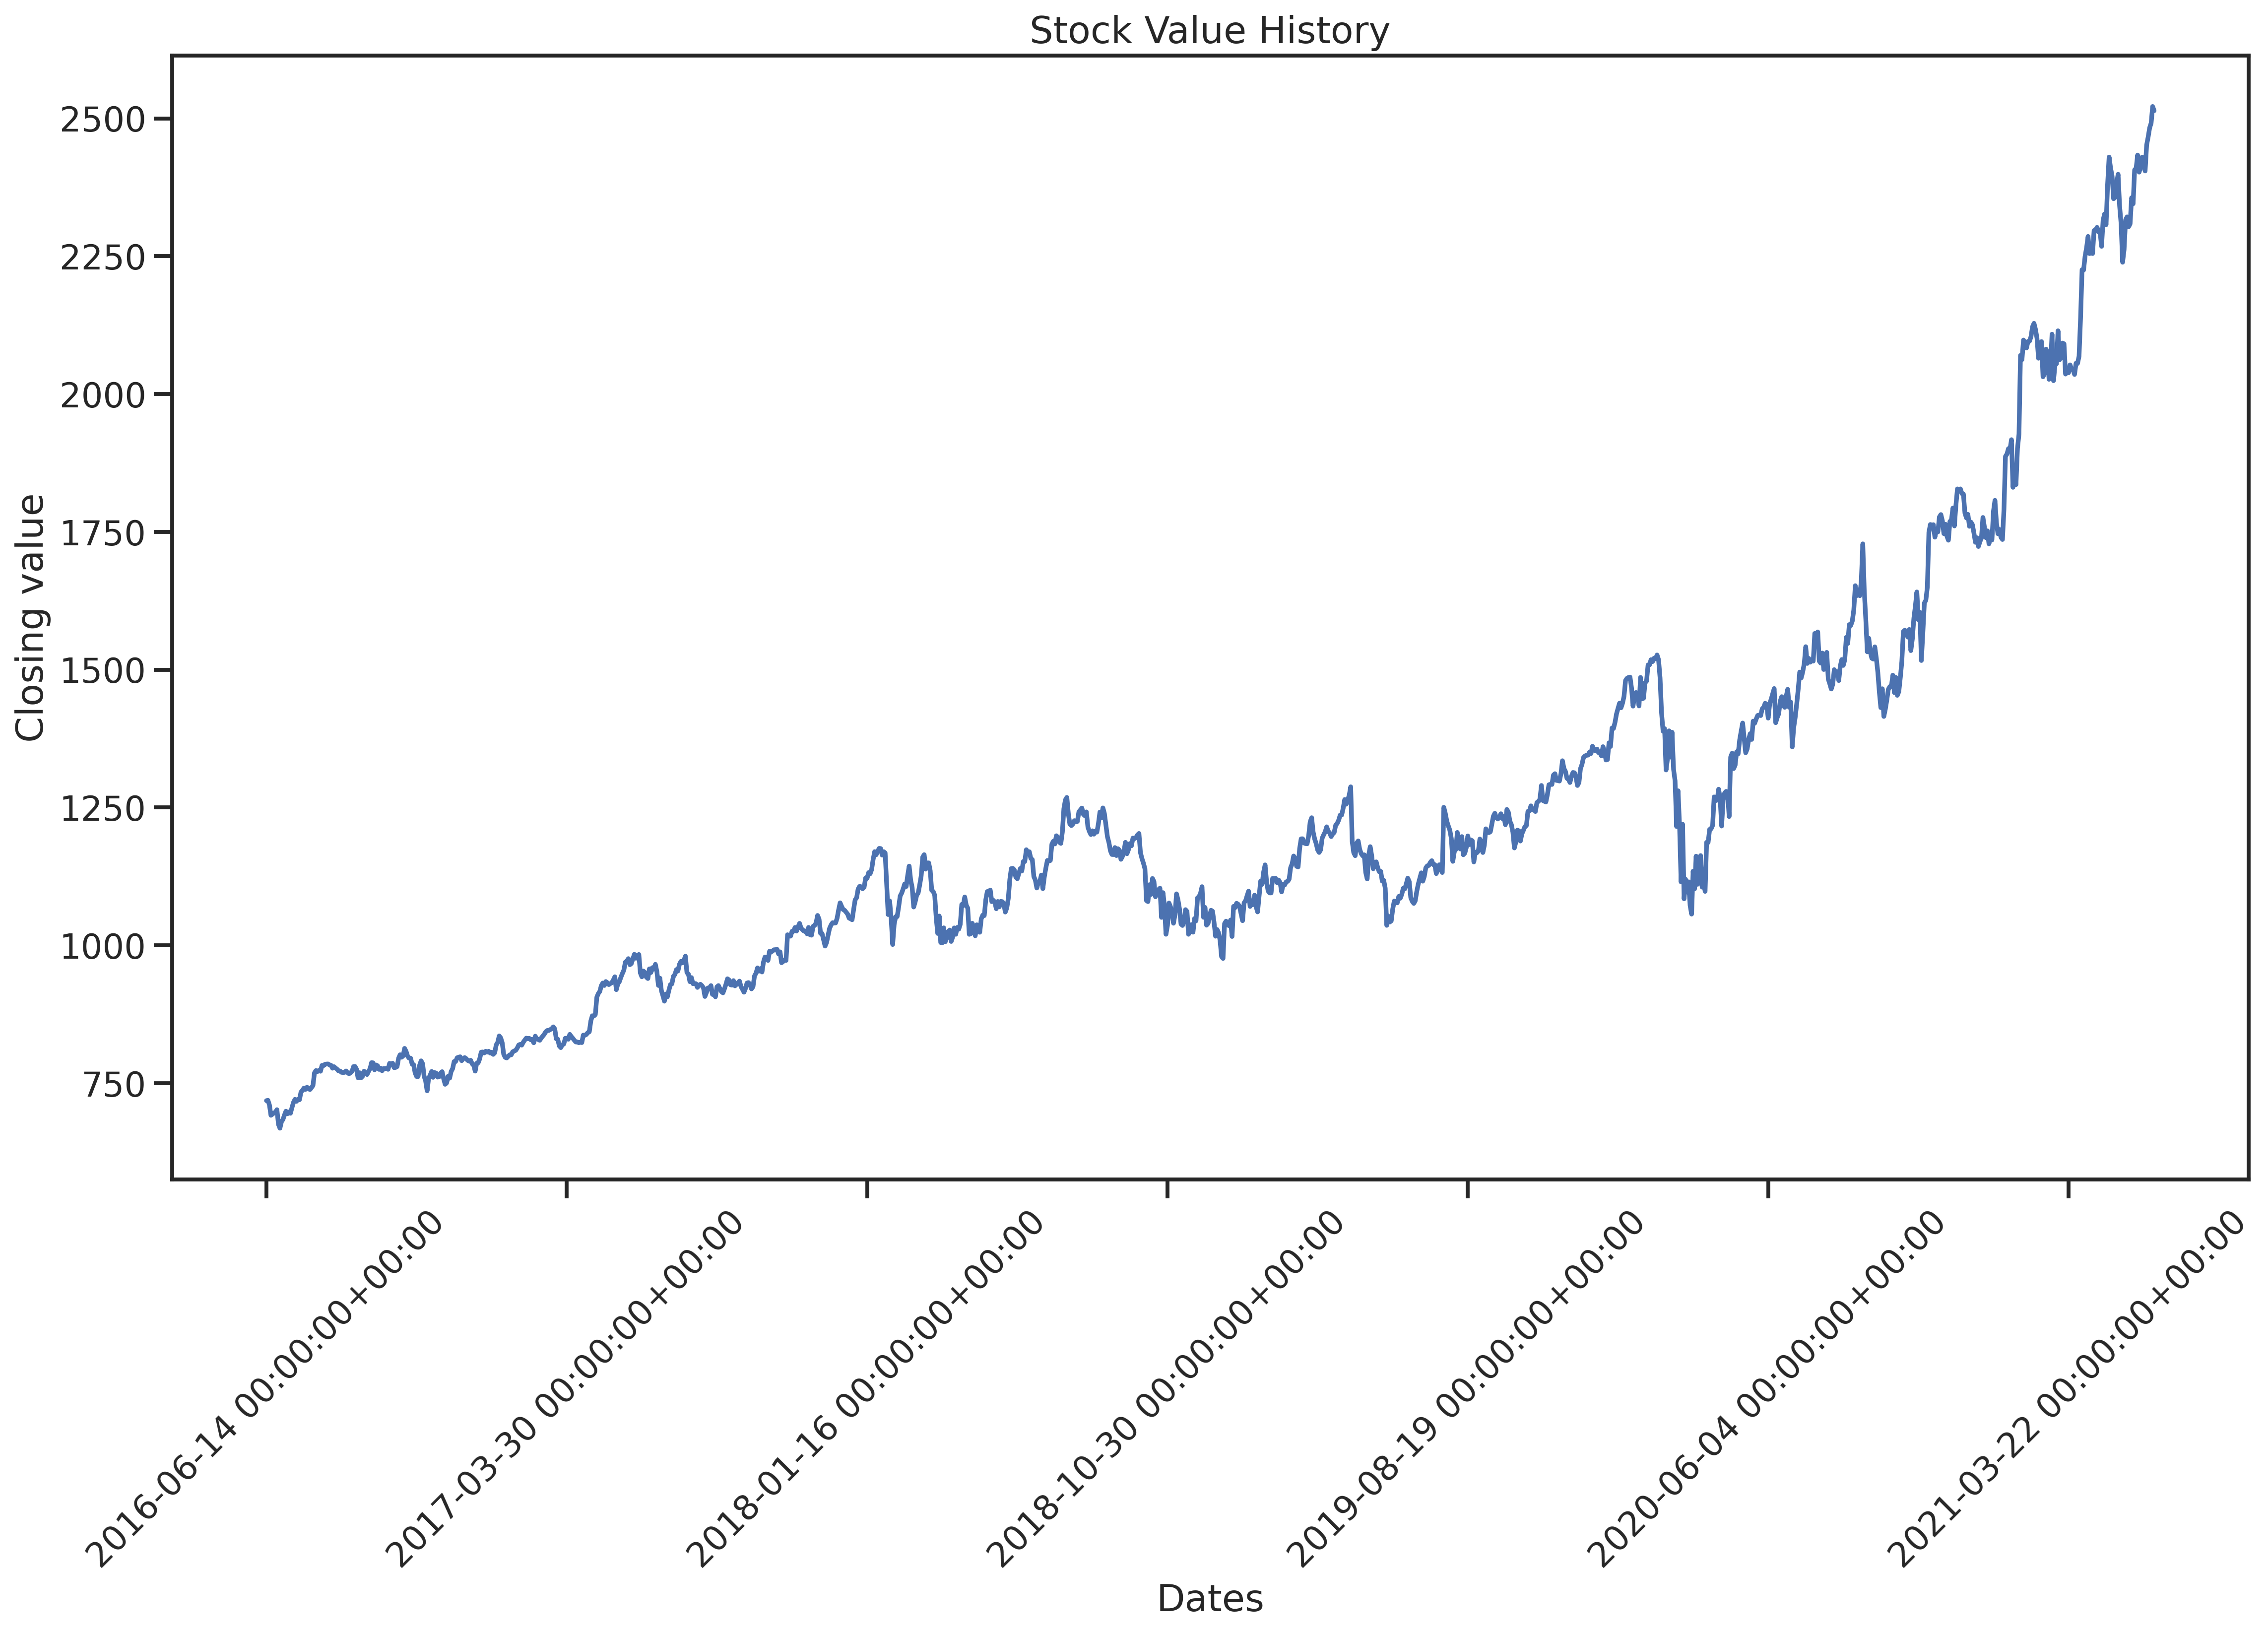

In [8]:
plt.figure(figsize= (18, 10))  # my figure size
plt.plot(df['close'])       # which attribute i want analyze
plt.xticks(range(0,df.shape[0],200), df['date'].loc[::200], rotation=45) # define what you wanna see in x axis
plt.title("Stock Value History", fontsize=18)
plt.xlabel('Dates', fontsize=18)
plt.ylabel('Closing value', fontsize=18)
plt.show()


### when dealing with sequential data, use time-series

In [24]:
from sklearn.preprocessing import MinMaxScaler

In [25]:
data_scaler = MinMaxScaler()  # create an instance of this class 

In [27]:
 close_df = data_scaler.fit_transform(close_df.reshape(-1, 1)) # use fit transform to modify the dataset

In [28]:
x_train = []
y_train = []

In [29]:
for i in range(30, len(close_df)):      # loop to iterate from 30 to the last index
    x_train.append(close_df[i-30:i,0])  # check the 30 preceding data 
    y_train.append(close_df[i, 0])      # loop to append the next day

In [31]:
x_train = np.array(x_train)
y_train = np.array(y_train)

In [32]:
print(x_train.shape)
print(y_train.shape)

(1228, 30)
(1228,)
